## Loading the InstaNovo model

We first install the latest instanovo from PyPi

In [ ]:
try:
  import instanovo
except ImportError:
  !uv pip install "instanovo[cu126]>=1.2.2" pyopenms-viz
  print('Installation complete. Restarting runtime to apply changes...')
  import os
  os.kill(os.getpid(), 9)

Using Python 3.12.13 environment at: /usr
Resolved 154 packages in 2.23s
Prepared 37 packages in 14.08s
Uninstalled 6 packages in 631ms
Installed 37 packages in 240ms
 + aiobotocore==2.26.0
 + aioitertools==0.13.0
 + boto3==1.41.5
 + botocore==1.41.5
 + bravado==11.1.0
 + bravado-core==6.1.1
 + deprecated==1.3.1
 + fastobo==0.14.1
 + hydra-core==1.3.2
 + instanovo==1.2.2
 + jaxtyping==0.3.9
 + jiwer==4.0.0
 + jmespath==1.1.0
 + jsonref==1.1.0
 - lxml==6.0.3
 + lxml==4.9.4
 + matchms==0.29.0
 + monotonic==1.6
 + neptune==1.14.0.post2
 - nvidia-nccl-cu12==2.27.5
 + nvidia-nccl-cu12==2.27.3
 - pandas==2.2.2
 + pandas==2.3.3
 + pickydict==0.5.0
 + pubchempy==1.0.5
 + pyopenms-viz==1.0.1
 + pyteomics==4.7.5
 + rapidfuzz==3.14.5
 + rdkit==2024.9.6
 + s3fs==2025.3.0
 + s3transfer==0.15.0
 + signalrcore==1.0.2
 + sparsestack==0.6.4
 + spectrum-utils==0.5.0
 + swagger-spec-validator==3.0.4
 - torch==2.10.0+cu128
 + torch==2.8.0
 + transfusion-asr==0.1.0
 - triton==3.6.0
 + triton==3.4.0
 + wadl

Set the device to GPU if available (recommended), otherwise use CPU.

In [ ]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
# Filter warnings and set logging level
import warnings
import logging

warnings.filterwarnings("ignore", module="matplotlib")
warnings.filterwarnings("ignore", module="torch")
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("rdkit").setLevel(logging.WARNING)

We can use `instanovo version` to check the version of InstaNovo (the transformer-based model), InstaNovo+ (the diffusion-based model) and some of their dependencies.

In [ ]:
!instanovo version

┏━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Package    ┃ Version ┃
┡━━━━━━━━━━━━╇━━━━━━━━━┩
│ InstaNovo  │ 1.2.2   │
│ InstaNovo+ │ 1.2.2   │
│ NumPy      │ 2.0.2   │
│ PyTorch    │ 2.8.0   │
└────────────┴─────────┘


Import the transformer-based InstaNovo model.

In [ ]:
from instanovo.transformer.model import InstaNovo

InstaNovo supports automatic model downloads. You can see the IDs of the pretrained models that are available.

In [ ]:
InstaNovo.get_pretrained()

['instanovo-v1.2.0',
 'instanovo-v1.1.0',
 'instanovo-v1.0.0',
 'instanovo-phospho-v1.0.0']

And download the model checkpoint given the ID.

In [ ]:
model, config = InstaNovo.from_pretrained("instanovo-v1.2.0")
model = model.to(device).eval()

## Loading the dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from instanovo.utils.data_handler import SpectrumDataFrame

# Lets do preprocessing for Waste water sample 1
sdf = SpectrumDataFrame.load_mzml("/content/drive/MyDrive/Wastewater/wastewater_Sample1_1.mzML")

In [ ]:
df = sdf.to_pandas().copy()

print("shape:", df.shape)
print(df.columns.tolist())
print(df.dtypes)
display(df.head(3))

shape: (17100, 8)
['scan_number', 'sequence', 'precursor_mass', 'precursor_mz', 'precursor_charge', 'retention_time', 'mz_array', 'intensity_array']
scan_number           int64
sequence             object
precursor_mass      float64
precursor_mz        float64
precursor_charge      int64
retention_time      float64
mz_array             object
intensity_array      object
dtype: object


,scan_number,sequence,precursor_mass,precursor_mz,precursor_charge,retention_time,mz_array,intensity_array
0,40,,1480.379368,741.19696,2,0.167837,"[136.38525390625, 143.05569458007812, 149.0447...","[1134.8853759765625, 1557.720458984375, 1477.0..."
1,166,,1366.393408,684.20398,2,0.711286,"[118.62577056884766, 149.045166015625, 167.055...","[1169.7818603515625, 3631.05126953125, 1690.52..."
2,257,,1514.430768,758.22266,2,1.103036,"[112.7114486694336, 112.89521789550781, 117.23...","[1333.8302001953125, 1128.4227294921875, 1125...."


In [ ]:
null_counts = df.isnull().sum()
print(null_counts)

scan_number         0
sequence            0
precursor_mass      0
precursor_mz        0
precursor_charge    0
retention_time      0
mz_array            0
intensity_array     0
dtype: int64


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

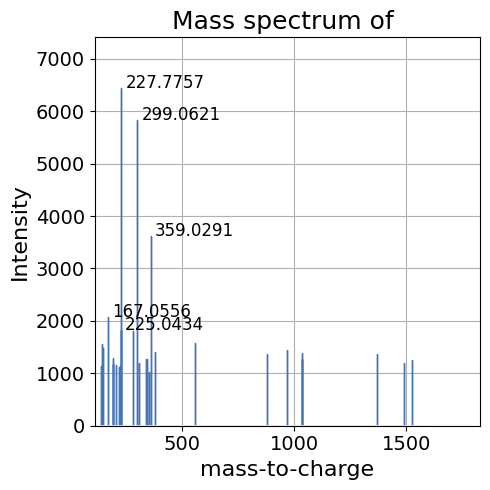

In [ ]:
import pandas as pd

pd.options.plotting.backend = "ms_matplotlib"
row = sdf[0]
row_df = pd.DataFrame({"mz": row["mz_array"], "intensity": row["intensity_array"]})
row_df.plot(
    kind="spectrum",
    x="mz",
    y="intensity",
    annotate_mz=True,
    bin_method="none",
    annotate_top_n_peaks=5,
    aggregate_duplicates=True,
    title=f"Mass spectrum of {row['sequence']}",
);

In [ ]:
# Lets do preprocessing for one of the Ecoli sample.

Ecoli_sdf = SpectrumDataFrame.load_mzml("/content/drive/MyDrive/E_coli/Ecoli_EV_1.mzML")

In [ ]:
Ecoli_df = Ecoli_sdf.to_pandas().copy()

print("shape:", Ecoli_df.shape)
print(Ecoli_df.columns.tolist())
print(Ecoli_df.dtypes)
display(Ecoli_df.head(3))

shape: (10881, 8)
['scan_number', 'sequence', 'precursor_mass', 'precursor_mz', 'precursor_charge', 'retention_time', 'mz_array', 'intensity_array']
scan_number           int64
sequence             object
precursor_mass      float64
precursor_mz        float64
precursor_charge      int64
retention_time      float64
mz_array             object
intensity_array      object
dtype: object


,scan_number,sequence,precursor_mass,precursor_mz,precursor_charge,retention_time,mz_array,intensity_array
0,95,,832.727148,417.37085,2,0.407458,"[108.90433879457866, 108.90479357490754, 108.9...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 677.9..."
1,169,,1301.626602,434.88281,3,0.726686,"[108.9043793591056, 108.90483413943026, 108.90...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 411.7..."
2,277,,840.644268,421.32941,2,1.194676,"[108.90433891446301, 108.90479369479279, 108.9...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 577.4..."


In [ ]:
ecoli_null_counts = df.isnull().sum()
print(ecoli_null_counts)

scan_number         0
sequence            0
precursor_mass      0
precursor_mz        0
precursor_charge    0
retention_time      0
mz_array            0
intensity_array     0
dtype: int64


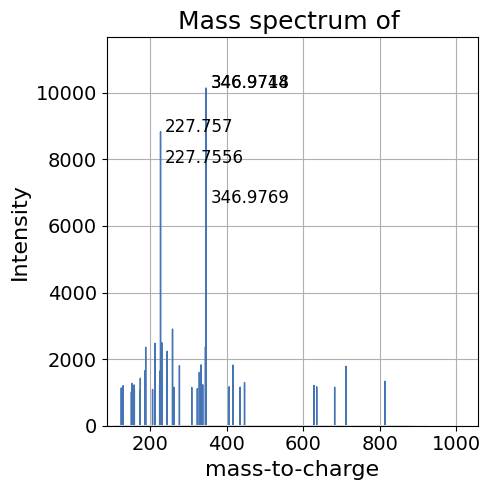

In [ ]:
import pandas as pd

pd.options.plotting.backend = "ms_matplotlib"
row = Ecoli_sdf[0]
row_df = pd.DataFrame({"mz": row["mz_array"], "intensity": row["intensity_array"]})
row_df.plot(
    kind="spectrum",
    x="mz",
    y="intensity",
    annotate_mz=True,
    bin_method="none",
    annotate_top_n_peaks=5,
    aggregate_duplicates=True,
    title=f"Mass spectrum of {row['sequence']}",
);

## Prediction

So we have one E. coli EV data with two fractions (Ecoli_EV_1 and Ecoli_EV_2). Results
from these two files can be combined.
We have two wastewater samples (wastewater_sample1 and wastewater_sample2). Each
has two fractions (*_1 and *_2). So combine the results from
wastewater_Sample1_1 and wastewater_Sample1_2 as Sample 1, and combine the
results from wastewater_Sample2_1 and wastewater_Sample2_2 as Sample 2

| Sample       | Input Files                                     | InstaNovo Output            | InstaNovo+ Output          | Casanovo Output           |
|--------------|-------------------------------------------------|-----------------------------|----------------------------|---------------------------|
| E. coli EV   | `Ecoli_EV_1.mzML`, `Ecoli_EV_2.mzML`            | `instanovo_Ecoli_preds.csv` | `instanovo+_Ecoli_preds.csv`| `casanovo_Ecoli_mzTab.tsv`|
| Wastewater 1 | `wastewater_Sample1_1.mzML`, `wastewater_Sample1_2.mzML` | `instanovo_wastewater1_preds.csv` | `instanovo+_wastewater1_preds.csv` | `casanovo_wastewater1_mzTab.tsv` |
| Wastewater 2 | `wastewater_Sample2_1.mzML`, `wastewater_Sample2_2.mzML` | `instanovo_wastewater2_preds.csv` | `instanovo+_wastewater2_preds.csv` | `casanovo_wastewater2_mzTab.tsv` |

In [ ]:
!ls /content/drive/MyDrive/Wastewater

wastewater_Sample1_1.mzML  wastewater_Sample2_1.mzML
wastewater_Sample1_2.mzML  wastewater_Sample2_2.mzML


In [ ]:
# InstaNovo (base model) predictions
!instanovo predict --data-path "/content/drive/MyDrive/E_coli/Ecoli_EV_1.mzML" --output-path instanovo_Ecoli_preds1.csv



[04/18/26 05:30:54] INFO     Initializing InstaNovo inference.                                                                                                                 
[04/18/26 05:30:56] INFO     NumExpr defaulting to 12 threads.                                                                                                                 
2026-04-18 05:30:59.376598: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-18 05:30:59.395468: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776490259.417826   16663 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when o

In [ ]:
!instanovo predict --data-path "/content/drive/MyDrive/E_coli/Ecoli_EV_2.mzML" --output-path instanovo_Ecoli_preds2.csv



[04/18/26 05:50:30] INFO     Initializing InstaNovo inference.                                                                                                                 
[04/18/26 05:50:32] INFO     NumExpr defaulting to 12 threads.                                                                                                                 
2026-04-18 05:50:35.011847: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-18 05:50:35.030931: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776491435.053441   21876 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when o

In [ ]:
import pandas as pd
import numpy as np
import re

ecoli_preds1 = pd.read_csv('instanovo_Ecoli_preds1.csv')
ecoli_preds2 = pd.read_csv('instanovo_Ecoli_preds2.csv')

# Tag each fraction so we can match to the correct DB search file later
ecoli_preds1['_fraction'] = 1
ecoli_preds2['_fraction'] = 2

ecoli_preds_all = pd.concat([ecoli_preds1, ecoli_preds2], ignore_index=True)
print(f'Total spectra (InstaNovo): {len(ecoli_preds_all)}')
print('Key columns:', [c for c in ecoli_preds_all.columns if 'scan' in c.lower() or 'pred' in c.lower() or 'diffusion' in c.lower()])

ecoli_preds_all[['instanovo_predictions', 'instanovoplus_predictions']].head(5)

Total spectra (InstaNovo): 21805
Key columns: ['scan_number', 'prediction_id', 'predictions', 'instanovo_predictions', 'instanovo_prediction_log_probability', 'instanovo_prediction_token_log_probabilities', 'instanovo_predictions_beam_0', 'instanovo_predictions_log_probability_beam_0', 'instanovo_predictions_token_log_probabilities_beam_0', 'instanovo_predictions_beam_1', 'instanovo_predictions_log_probability_beam_1', 'instanovo_predictions_token_log_probabilities_beam_1', 'instanovo_predictions_beam_2', 'instanovo_predictions_log_probability_beam_2', 'instanovo_predictions_token_log_probabilities_beam_2', 'instanovo_predictions_beam_3', 'instanovo_predictions_log_probability_beam_3', 'instanovo_predictions_token_log_probabilities_beam_3', 'instanovo_predictions_beam_4', 'instanovo_predictions_log_probability_beam_4', 'instanovo_predictions_token_log_probabilities_beam_4', 'instanovoplus_predictions', 'instanovoplus_prediction_log_probability', 'instanovoplus_prediction_token_log_prob

,instanovo_predictions,instanovoplus_predictions
0,"['S', 'P', 'S[UNIMOD:21]', 'L', 'S', 'P', 'K']","['C[UNIMOD:4]', 'V', 'E', 'L', 'S', 'P', 'K']"
1,"['L', 'A', 'L', 'A', 'G', 'G', 'G', 'I', 'A', ...","['A', 'A', 'S', 'E', 'G', 'G', 'Q', 'S', 'S', ..."
2,"['G', 'E', 'M[UNIMOD:35]', 'G', 'G', 'Y', 'G',...","['G', 'P', 'N', 'G', 'G', 'Y', 'G', 'K']"
3,"['A', 'P', 'S[UNIMOD:21]', 'P', 'P', 'P', 'R']","['E', 'V', 'F', 'P', 'P', 'N', 'R']"
4,"['V', 'E', 'G', 'A', 'L', 'S', 'E', 'V', 'T', ...","['M[UNIMOD:35]', 'V', 'G', 'A', 'L', 'S', 'M',..."


In [ ]:
#Helper functions
def parse_prediction_sequence(x):
    """
    Converts prediction entries like:
    "['C[UNIMOD:4]', 'K', 'P', 'T']"
    into:
    "C[UNIMOD:4]KPT"
    """
    if pd.isna(x):
        return ''
    x = str(x).strip()
    if x == '':
        return ''
    if x.startswith('['):
        try:
            toks = ast.literal_eval(x)
            if isinstance(toks, list):
                return ''.join(str(t) for t in toks)
        except Exception:
            return ''
    return x


def normalize_for_unmodified_eval(seq, collapse_il=False):
    """
    Makes DB search sequences and InstaNovo predictions comparable.

    - removes surrounding underscores from DB modified sequence if any
    - removes [UNIMOD:xx] annotations
    - keeps only amino-acid letters
    - optional: collapse I -> L if you want I/L-insensitive evaluation
    """
    if pd.isna(seq):
        return ''
    seq = str(seq).strip().upper()
    seq = seq.replace('_', '')
    seq = re.sub(r'\[.*?\]', '', seq)   # remove UNIMOD tags
    seq = re.sub(r'[^A-Z]', '', seq)    # keep only letters
    if collapse_il:
        seq = seq.replace('I', 'L')
    return seq


def pick_best_prediction_per_scan(df):
    """
    Keep only one prediction row per (fraction, scan_number).
    If prediction_id exists, keep the smallest one (usually 0 / best).
    """
    out = df.copy()

    if 'prediction_id' in out.columns:
        out = out.sort_values(['_fraction', 'scan_number', 'prediction_id'])
    else:
        out = out.sort_values(['_fraction', 'scan_number'])

    out = out.drop_duplicates(subset=['_fraction', 'scan_number'], keep='first')
    return out

In [ ]:
# Parse and normalize model predictions

ecoli_preds_all = pick_best_prediction_per_scan(ecoli_preds_all)

ecoli_preds_all['instanovo_seq_raw'] = ecoli_preds_all['instanovo_predictions'].apply(parse_prediction_sequence)
ecoli_preds_all['instanovop_seq_raw'] = ecoli_preds_all['instanovoplus_predictions'].apply(parse_prediction_sequence)

# Normalized versions used for evaluation
ecoli_preds_all['instanovo_eval'] = ecoli_preds_all['instanovo_seq_raw'].apply(normalize_for_unmodified_eval)
ecoli_preds_all['instanovop_eval'] = ecoli_preds_all['instanovop_seq_raw'].apply(normalize_for_unmodified_eval)

print(f'Total unique spectra after deduplication: {len(ecoli_preds_all)}')
print('\nSample parsed predictions:')
display(
    ecoli_preds_all[
        ['scan_number', '_fraction', 'instanovo_seq_raw', 'instanovop_seq_raw', 'instanovo_eval', 'instanovop_eval']
    ].head(5)
)

Total unique spectra after deduplication: 21805

Sample parsed predictions:


,scan_number,_fraction,instanovo_seq_raw,instanovop_seq_raw,instanovo_eval,instanovop_eval
0,95,1,SPS[UNIMOD:21]LSPK,C[UNIMOD:4]VELSPK,SPSLSPK,CVELSPK
1,169,1,LALAGGGIAPALLR,AASEGGQSSPAALR,LALAGGGIAPALLR,AASEGGQSSPAALR
2,277,1,GEM[UNIMOD:35]GGYGK,GPNGGYGK,GEMGGYGK,GPNGGYGK
3,421,1,APS[UNIMOD:21]PPPR,EVFPPNR,APSPPPR,EVFPPNR
4,467,1,VEGALSEVTELSR,M[UNIMOD:35]VGALSMVTELSR,VEGALSEVTELSR,MVGALSMVTELSR


In [ ]:

# Load DB search results
db1 = pd.read_excel('/content/drive/MyDrive/E_coli/Database_search_output_Ecoli_EV_1.xlsx')
db2 = pd.read_excel('/content/drive/MyDrive/E_coli/Database_search_output_Ecoli_EV_2.xlsx')

db1['_fraction'] = 1
db2['_fraction'] = 2

db_combined = pd.concat([db1, db2], ignore_index=True)

print(f'Total raw DB rows: {len(db_combined)}')
print('DB columns:')
print(db_combined.columns.tolist())

Total raw DB rows: 3162
DB columns:
['Scan number', 'Scan index', 'Sequence', 'Length', 'Missed cleavages', 'Modifications', 'Modified sequence', 'Oxidation (M) Probabilities', 'Oxidation (M) Score diffs', 'Acetyl (Protein N-term)', 'Oxidation (M)', 'Charge', 'Scan event number', 'm/z', 'Mass', 'Mass error [ppm]', 'Mass error [Da]', 'Simple mass error [ppm]', 'Retention time', 'PEP', 'Score', 'Delta score', 'Precursor full scan number', 'Precursor Intensity', 'Precursor apex fraction', 'Precursor apex offset', 'Precursor apex offset time', 'Matches', 'Intensities', 'Mass deviations [Da]', 'Mass deviations [ppm]', 'Masses', 'Number of matches', 'Intensity coverage', 'Peak coverage', 'Unfragmented precursor intensity', 'Unfragmented precursor fraction', 'Neutral loss level', 'ETD identification type', 'Contaminant', '_fraction']


In [ ]:

# Clean DB search results
db_eval = db_combined.copy()


db_eval = db_eval.dropna(subset=['Sequence'])
db_eval = db_eval[db_eval['Sequence'].astype(str).str.strip() != '']

# we will remove contaminants if such a column exists
if 'Contaminant' in db_eval.columns:
    contam = db_eval['Contaminant'].astype(str).str.strip().str.lower()
    db_eval = db_eval[
        contam.isin(['', 'nan', '0', 'false', 'no']) | db_eval['Contaminant'].isna()
    ]

# we will keep rank-1 hit if a rank column exists
rank_candidates = ['Rank', 'Search Engine Rank', 'PSM Rank']
for col in rank_candidates:
    if col in db_eval.columns:
        db_eval[col] = pd.to_numeric(db_eval[col], errors='coerce')
        db_eval = db_eval[(db_eval[col].isna()) | (db_eval[col] == 1)]
        print(f'Applied rank filter using column: {col}')
        break

# we will keep high-confidence IDs if a q-value / FDR column exists
qval_candidates = ['Percolator q-Value', 'QValue', 'Q-value', 'q-value', 'FDR']
for col in qval_candidates:
    if col in db_eval.columns:
        db_eval[col] = pd.to_numeric(db_eval[col], errors='coerce')
        before = len(db_eval)
        db_eval = db_eval[(db_eval[col].isna()) | (db_eval[col] <= 0.01)]
        print(f'Applied confidence filter using {col} <= 0.01 | kept {len(db_eval)}/{before}')
        break

# we will Normalize DB peptide strings for fair comparison
db_eval['db_seq_raw'] = db_eval['Sequence'].astype(str)
db_eval['db_seq_eval'] = db_eval['db_seq_raw'].apply(normalize_for_unmodified_eval)

# If same scan appears multiple times, keep the first after sorting by available score column
score_candidates_desc = ['Hyperscore', 'Score', 'XCorr', 'Confidence']
sort_cols = ['_fraction', 'Scan number']
ascending = [True, True]

for col in score_candidates_desc:
    if col in db_eval.columns:
        db_eval[col] = pd.to_numeric(db_eval[col], errors='coerce')
        sort_cols.append(col)
        ascending.append(False)
        print(f'Using {col} to resolve duplicate DB hits per scan.')
        break

db_eval = db_eval.sort_values(sort_cols, ascending=ascending)
db_eval = db_eval.drop_duplicates(subset=['_fraction', 'Scan number'], keep='first')

print(f'Final DB rows used for evaluation: {len(db_eval)}')
display(db_eval[['Scan number', '_fraction', 'db_seq_raw', 'db_seq_eval']].head(5))

Using Score to resolve duplicate DB hits per scan.
Final DB rows used for evaluation: 3009


,Scan number,_fraction,db_seq_raw,db_seq_eval
0,1636,1,CKPTSPGR,CKPTSPGR
1,1664,1,SHALNATK,SHALNATK
2,1720,1,SFSHQAGASSK,SFSHQAGASSK
4,1740,1,SHALNATK,SHALNATK
5,1746,1,IEQAPGQHGAR,IEQAPGQHGAR


In [ ]:
# Merge DB search results with predictions
preds_merge = ecoli_preds_all[
    ['scan_number', '_fraction', 'instanovo_seq_raw', 'instanovop_seq_raw', 'instanovo_eval', 'instanovop_eval']
].copy()
preds_merge = preds_merge.rename(columns={'scan_number': 'Scan number'})

db_merge = db_eval[
    ['Scan number', '_fraction', 'db_seq_raw', 'db_seq_eval']
].copy()

merged = pd.merge(
    db_merge,
    preds_merge,
    on=['Scan number', '_fraction'],
    how='inner'
)

print(f'DB rows after cleaning       : {len(db_eval)}')
print(f'Prediction rows after dedupe : {len(ecoli_preds_all)}')
print(f'Matched spectra for eval     : {len(merged)}')
print(f'Match coverage vs DB         : {len(merged) / len(db_eval):.4f}')

display(
    merged[
        ['Scan number', '_fraction', 'db_seq_raw', 'instanovo_seq_raw', 'instanovop_seq_raw', 'db_seq_eval', 'instanovo_eval', 'instanovop_eval']
    ].head(10)
)

DB rows after cleaning       : 3009
Prediction rows after dedupe : 21805
Matched spectra for eval     : 3009
Match coverage vs DB         : 1.0000


,Scan number,_fraction,db_seq_raw,instanovo_seq_raw,instanovop_seq_raw,db_seq_eval,instanovo_eval,instanovop_eval
0,1636,1,CKPTSPGR,C[UNIMOD:4]KPTSPGR,C[UNIMOD:4]KPTSPGR,CKPTSPGR,CKPTSPGR,CKPTSPGR
1,1664,1,SHALNATK,SHALNATK,SHALNATK,SHALNATK,SHALNATK,SHALNATK
2,1720,1,SFSHQAGASSK,SFSHQAGASSK,SFSHQAGASSK,SFSHQAGASSK,SFSHQAGASSK,SFSHQAGASSK
3,1740,1,SHALNATK,TPGAGTGLGKSHAINATK,[UNIMOD:5]GGAINSLGKSHAINATK,SHALNATK,TPGAGTGLGKSHAINATK,GGAINSLGKSHAINATK
4,1746,1,IEQAPGQHGAR,LEQAPGQHGAR,LEQAPGQHGAR,IEQAPGQHGAR,LEQAPGQHGAR,LEQAPGQHGAR
5,1756,1,IGHTVER,LGHTVER,LGHTVER,IGHTVER,LGHTVER,LGHTVER
6,1757,1,SATDAANAAQNR,SATDAANAAQNR,SATDAANAAQNR,SATDAANAAQNR,SATDAANAAQNR,SATDAANAAQNR
7,1793,1,RYPNNPGAK,RYPNNPGAK,RYPNNPGAK,RYPNNPGAK,RYPNNPGAK,RYPNNPGAK
8,1816,1,QIDANQGGNQR,QIDANQGGNQR,QIDANQGGNQR,QIDANQGGNQR,QIDANQGGNQR,QIDANQGGNQR
9,1842,1,NHPAPQAPR,NHPAPQAPR,NHPAPQAPR,NHPAPQAPR,NHPAPQAPR,NHPAPQAPR


In [ ]:
# Precision / Recall evaluation
from instanovo.utils.metrics import Metrics

db_gt         = merged['db_seq_eval'].tolist()
preds_inovo   = merged['instanovo_eval'].tolist()
preds_inovo_p = merged['instanovop_eval'].tolist()


print(f'Evaluation pairs: {len(db_gt)}')
print('\nGround truth :', db_gt[:5])
print('InstaNovo    :', preds_inovo[:5])
print('InstaNovo+   :', preds_inovo_p[:5])

metrics_eval = Metrics(model.residue_set, config['isotope_error_range'])


aa_prec_in, aa_rec_in, pep_rec_in, pep_prec_in = metrics_eval.compute_precision_recall(db_gt, preds_inovo)
aa_prec_ip, aa_rec_ip, pep_rec_ip, pep_prec_ip = metrics_eval.compute_precision_recall(db_gt, preds_inovo_p)

summary = pd.DataFrame({
    'Model': ['InstaNovo', 'InstaNovo+'],
    'AA Precision': [aa_prec_in, aa_prec_ip],
    'AA Recall': [aa_rec_in, aa_rec_ip],
    'Peptide Precision': [pep_prec_in, pep_prec_ip],
    'Peptide Recall': [pep_rec_in, pep_rec_ip],
})

print('\n E. coli evaluation against database-search results ')
display(summary.style.format({
    'AA Precision': '{:.4f}',
    'AA Recall': '{:.4f}',
    'Peptide Precision': '{:.4f}',
    'Peptide Recall': '{:.4f}',
}))

Evaluation pairs: 3009

Ground truth : ['CKPTSPGR', 'SHALNATK', 'SFSHQAGASSK', 'SHALNATK', 'IEQAPGQHGAR']
InstaNovo    : ['CKPTSPGR', 'SHALNATK', 'SFSHQAGASSK', 'TPGAGTGLGKSHAINATK', 'LEQAPGQHGAR']
InstaNovo+   : ['CKPTSPGR', 'SHALNATK', 'SFSHQAGASSK', 'GGAINSLGKSHAINATK', 'LEQAPGQHGAR']

 E. coli evaluation against database-search results 


,Model,AA Precision,AA Recall,Peptide Precision,Peptide Recall
0,InstaNovo,0.6152,0.6191,0.5769,0.5769
1,InstaNovo+,0.6587,0.6650,0.6035,0.6035


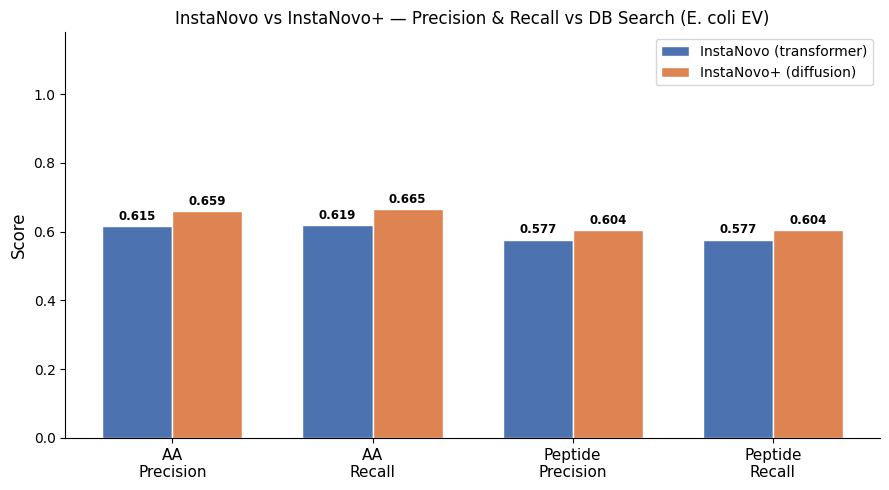

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metric_labels = ['AA\nPrecision', 'AA\nRecall', 'Peptide\nPrecision', 'Peptide\nRecall']

inovo_vals  = [aa_prec_in,  aa_rec_in,  pep_prec_in,  pep_rec_in]
inovoP_vals = [aa_prec_ip, aa_rec_ip, pep_prec_ip, pep_rec_ip]

x     = np.arange(len(metric_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

bars1 = ax.bar(
    x - width/2, inovo_vals, width,
    label='InstaNovo (transformer)',
    color='#4C72B0', edgecolor='white'
)

bars2 = ax.bar(
    x + width/2, inovoP_vals, width,
    label='InstaNovo+ (diffusion)',
    color='#DD8452', edgecolor='white'
)


for bar, val in list(zip(bars1, inovo_vals)) + list(zip(bars2, inovoP_vals)):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{val:.3f}',
        ha='center',
        va='bottom',
        fontsize=8.5,
        fontweight='bold'
    )

ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0, 1.18)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(
    'InstaNovo vs InstaNovo+ — Precision & Recall vs DB Search (E. coli EV)',
    fontsize=12
)

ax.legend(fontsize=10)


ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('ecoli_instanovo_vs_instanovoplus.png', dpi=150)
plt.show()

In [ ]:
!instanovo predict --data-path wastewater_Sample1_1.mzML --output-path instanovo_waste1_preds1.csv


In [ ]:
!instanovo predict --data-path wastewater_Sample1_2.mzML --output-path instanovo_waste1_preds2.csv



In [ ]:
!instanovo predict --data-path wastewater_Sample2_1.mzML --output-path instanovo_waste2_preds1.csv


In [ ]:
!instanovo predict --data-path wastewater_Sample2_2.mzML --output-path instanovo_waste2_preds2.csv